# Capstone --- Combining Predictive Techniques



**Business scenario:** You are helping Lending Club build a second-opinion risk model. Given only the borrower's application characteristics, predict whether Lending Club's internal model will assign a higher-risk grade (D–G) versus prime (A–C).

**Target:** `risky_grade` = 1 if `grade` in {D, E, F, G}; 0 if in {A, B, C}.

**Before you start:** read `topic_capstone_combining_predictive_techniques_instructions.pdf`. Use Claude Code to help you fill in each section. You must be able to explain every line of code you run --- either team member may be asked to walk through any cell during the May 4 walkthrough.

**Reproducibility:** Use `random_state=42` everywhere.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
pd.set_option('display.max_columns', 60)

## 1. Problem Statement

Lending club already assigns each applicant a loan grade but the business wants a second opinion model that uses only application time information. The target of this notebook is risky_grade, where grades A-c are coded as 0 and grades D-G are coded as 1. This matters because a stong 2nd opinion model can help lending club flag applicants who appear riskier before funding decisions are finalized. To stay realistic, i will remove leakage variables and compare 4 predictive models using the same cleaned data and the same preprocrssing pipeline. 

## Load the raw data

In [2]:
loans = pd.read_csv('data/lending_club_raw.csv')  # dataset not included in repo; download separately
print('Shape:', loans.shape)
loans.head()

Shape: (10000, 55)


,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,total_credit_utilized,num_collections_last_12m,num_historical_failed_to_pay,months_since_90d_late,current_accounts_delinq,total_collection_amount_ever,current_installment_accounts,accounts_opened_24m,months_since_last_credit_inquiry,num_satisfactory_accounts,num_accounts_120d_past_due,num_accounts_30d_past_due,num_active_debit_accounts,total_debit_limit,num_total_cc_accounts,num_open_cc_accounts,num_cc_carrying_balance,num_mort_accounts,account_never_delinq_percent,tax_liens,public_record_bankrupt,loan_purpose,application_type,loan_amount,term,interest_rate,installment,grade,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,NaN,0,38.0,2001,6,28,10,70795,38767,0,0,38.0,0,1250,2,5,5.0,10,0.0,0,2,11100,14,8,6,1,92.9,0,0,moving,individual,28000,60,14.07,652.53,C,C3,Mar-2018,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,NaN,0,NaN,1996,1,30,14,28800,4321,0,1,NaN,0,0,0,11,8.0,14,0.0,0,3,16500,24,14,4,0,100.0,0,1,debt_consolidation,individual,5000,36,12.61,167.54,C,C1,Feb-2018,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,NaN,0,28.0,2006,4,31,10,24193,16000,0,0,28.0,0,432,1,13,7.0,10,0.0,0,3,4300,14,8,6,0,93.5,0,0,other,individual,2000,36,17.09,71.40,D,D1,Feb-2018,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,NaN,0,NaN,2007,0,4,4,25400,4997,0,1,NaN,0,0,1,1,15.0,4,0.0,0,2,19400,3,3,2,0,100.0,1,0,debt_consolidation,individual,21600,36,6.72,664.19,A,A3,Jan-2018,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,0,NaN,2008,7,22,16,69839,52722,0,0,NaN,0,0,1,6,4.0,16,0.0,0,10,32700,20,15,13,0,100.0,0,0,credit_card,joint,23000,36,14.07,786.87,C,C3,Mar-2018,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


### Inspection: dtypes and missingness

Use the output below to plan your cleaning. Look for:
- columns stored as strings that should be numeric
- columns with heavy missingness

In [3]:
print(loans.dtypes.value_counts())
print('\nMissing percentages (only columns with at least one missing value):')
missing_pct = (loans.isna().mean() * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0].round(2))

int64      25
float64    17
object     13
Name: count, dtype: int64

Missing percentages (only columns with at least one missing value):
verification_income_joint           85.45
debt_to_income_joint                85.05
annual_income_joint                 85.05
months_since_90d_late               77.15
months_since_last_delinq            56.58
months_since_last_credit_inquiry    12.71
emp_title                            8.33
emp_length                           8.17
num_accounts_120d_past_due           3.18
debt_to_income                       0.24
dtype: float64


## 2. Exploratory Data Analysis

**Required:** at least three visualizations, each with a one- or two-sentence caption.

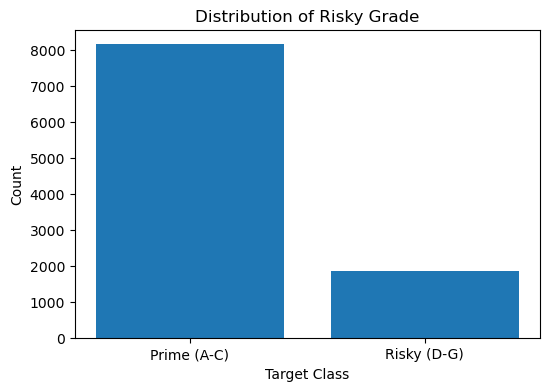

risky_grade
0    0.8149
1    0.1851
Name: proportion, dtype: float64

In [4]:
# TODO: engineer the target so you can plot its distribution
loans['risky_grade'] = loans['grade'].isin(['D', 'E', 'F', 'G']).astype(int)

target_counts = loans['risky_grade'].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(target_counts.index.map({0: 'Prime (A-C)', 1: 'Risky (D-G)'}), target_counts.values)
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.title('Distribution of Risky Grade')
plt.show()

loans['risky_grade'].value_counts(normalize=True).rename('proportion').round(4)
# TODO: visualization 1 --- target distribution

The target is imbalanced, only about 18.5% of loans are risky grade. This matters because accuarcy alone could look good even inf a model misses many risky borrowers. 

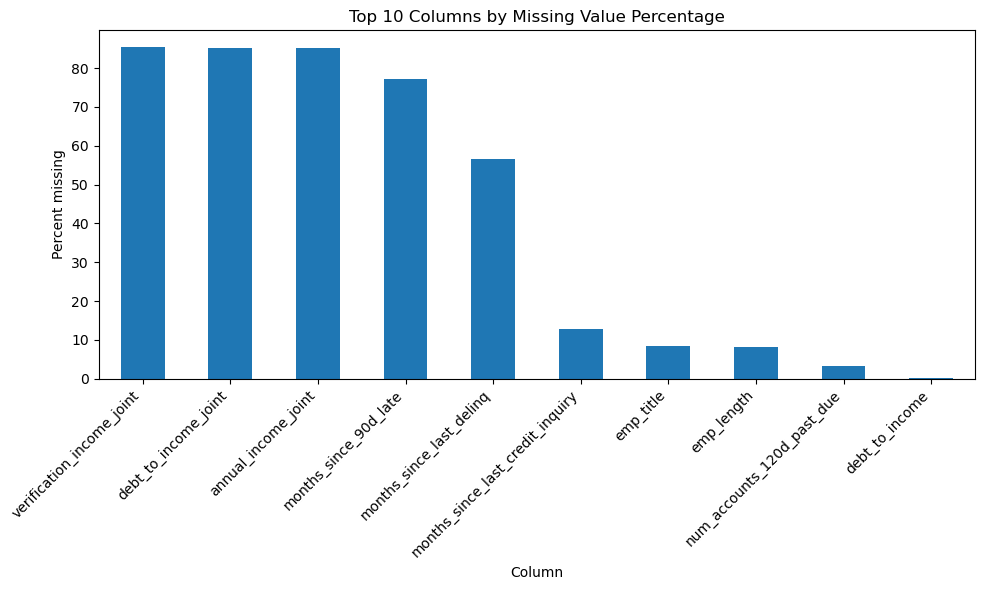

verification_income_joint           85.45
debt_to_income_joint                85.05
annual_income_joint                 85.05
months_since_90d_late               77.15
months_since_last_delinq            56.58
months_since_last_credit_inquiry    12.71
emp_title                            8.33
emp_length                           8.17
num_accounts_120d_past_due           3.18
debt_to_income                       0.24
dtype: float64

In [5]:
# TODO: visualization 2 --- missing-value pattern

missing_plot =(loans.isna().mean()*100).sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
missing_plot.plot(kind='bar')
plt.ylabel('Percent missing')
plt.xlabel('Column')
plt.title('Top 10 Columns by Missing Value Percentage')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
missing_plot.round(2)

Missingness is concentrated in the joint application fields and in delinquency timing fields. the pattern suggest some missing values are structual, not random, so i should't blindly drop the affected rows



<Figure size 1000x600 with 0 Axes>

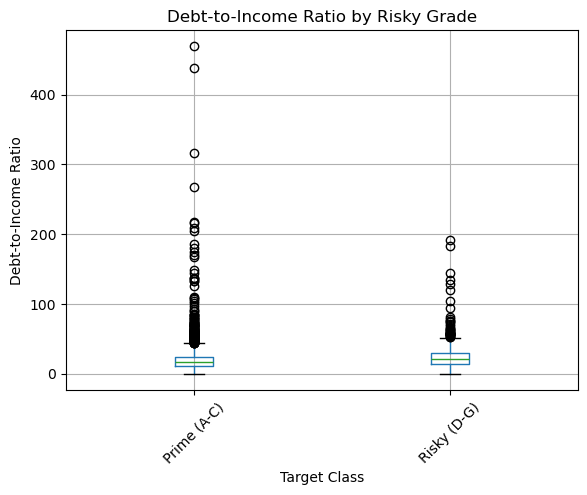

risky_grade
0    16.88
1    21.19
Name: debt_to_income, dtype: float64

In [6]:
# TODO: visualization 3 --- relationship between a numeric feature and the target

plot_df=loans[['risky_grade', 'debt_to_income']].dropna()
plot_df['target_label'] = plot_df['risky_grade'].map({0: 'Prime (A-C)', 1: 'Risky (D-G)'})

plt.figure(figsize=(10, 6))
plot_df.boxplot(column='debt_to_income', by='target_label')
plt.suptitle('')
plt.title('Debt-to-Income Ratio by Risky Grade')
plt.xlabel('Target Class')
plt.ylabel('Debt-to-Income Ratio')
plt.xticks(rotation=45)
plt.show()

loans.groupby('risky_grade')['debt_to_income'].median()

Risky grade loans tend to have a higher debt to income ration than prime loans. That makes debt burden a plausable predictor and confirms that some application time financial variables should carry real signal.



## 3. Data Cleaning

For every cleaning step, write a short markdown cell before the code explaining **what** you did and **why**.

### 3.1 Drop the data-leakage columns

The columns listed in `LEAKAGE_COLUMNS` below are provided explicitly in the project instructions. They are either the target itself (derived from `grade`) or values that Lending Club only records after the loan has been issued. You must remove all of them before training any model.

**Before the code cell:** add a markdown cell above each leakage column (or in a single grouped cell) explaining in one sentence why each one is a leakage feature. You are not asked to discover the list --- you are asked to explain it.

In [7]:
# Explicit leakage columns --- listed in the instructions PDF.
# You must drop all of these before training any model.
LEAKAGE_COLUMNS = [
    'grade',                  # target is derived from this column
    'sub_grade',              # finer version of grade; same leakage
    'interest_rate',          # set by Lending Club based on grade
    'installment',            # derived from loan_amount, term, interest_rate
    'loan_status',            # post-origination outcome
    'initial_listing_status', # only known after Lending Club approves the loan
    'disbursement_method',    # only known after approval
    'balance',                # post-origination balance
    'paid_total',             # post-origination payment outcome
    'paid_principal',         # post-origination payment outcome
    'paid_interest',          # post-origination payment outcome
    'paid_late_fees',         # post-origination payment outcome
]

# TODO: engineer the target from `grade`, then drop LEAKAGE_COLUMNS.
# loans['risky_grade'] = loans['grade'].isin(['D','E','F','G']).astype(int)
# loans_clean = loans.drop(columns=LEAKAGE_COLUMNS)

LEAKAGE_COLUMNS = ['grade', 'sub_grade', 'interest_rate', 'installment', 'loan_status', 'initial_listing_status', 'disbursement_method', 'balance', 'paid_total', 'paid_principal', 'paid_interest', 'paid_late_fees']

model_df = loans.drop(columns=LEAKAGE_COLUMNS)
print('Shape after dropping leakage columns:', model_df.shape)
model_df.head()

Shape after dropping leakage columns: (10000, 44)


,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,total_credit_utilized,num_collections_last_12m,num_historical_failed_to_pay,months_since_90d_late,current_accounts_delinq,total_collection_amount_ever,current_installment_accounts,accounts_opened_24m,months_since_last_credit_inquiry,num_satisfactory_accounts,num_accounts_120d_past_due,num_accounts_30d_past_due,num_active_debit_accounts,total_debit_limit,num_total_cc_accounts,num_open_cc_accounts,num_cc_carrying_balance,num_mort_accounts,account_never_delinq_percent,tax_liens,public_record_bankrupt,loan_purpose,application_type,loan_amount,term,issue_month,risky_grade
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,NaN,0,38.0,2001,6,28,10,70795,38767,0,0,38.0,0,1250,2,5,5.0,10,0.0,0,2,11100,14,8,6,1,92.9,0,0,moving,individual,28000,60,Mar-2018,0
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,NaN,0,NaN,1996,1,30,14,28800,4321,0,1,NaN,0,0,0,11,8.0,14,0.0,0,3,16500,24,14,4,0,100.0,0,1,debt_consolidation,individual,5000,36,Feb-2018,0
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,NaN,0,28.0,2006,4,31,10,24193,16000,0,0,28.0,0,432,1,13,7.0,10,0.0,0,3,4300,14,8,6,0,93.5,0,0,other,individual,2000,36,Feb-2018,1
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,NaN,0,NaN,2007,0,4,4,25400,4997,0,1,NaN,0,0,1,1,15.0,4,0.0,0,2,19400,3,3,2,0,100.0,1,0,debt_consolidation,individual,21600,36,Jan-2018,0
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,0,NaN,2008,7,22,16,69839,52722,0,0,NaN,0,0,1,6,4.0,16,0.0,0,10,32700,20,15,13,0,100.0,0,0,credit_card,joint,23000,36,Mar-2018,0


### 3.2 Missing-value strategy

3 main missing value decisions.
1. Fill the joint application columns: annual_income_joint and debt_to_income are missing for individual loans because those loans are not joint applications. i fill those with 0 and fill verification_income_joint with 'not join' so the missingness becomes an explicit category instead of noise
2. Keep the remaining partially missing numeric fields and impute later inside the pipeline: emp_length, months_since_last_deling, months_since_90d_late, and months_since_last_credit_inquiry still contain useful application time information. Their imputation should be fit on a training data only so the actual median imputation happens later inside the shared preprocessing pipeline. 
3. Drop emp_title: It has thousands of unique free text job titles and about 8% missingness. one hot encoding it would create a very large sparse feature set that is hard to explain in a capstone notebook

In [8]:
# TODO: handle missing values by column group
model_df = model_df.drop(columns=['emp_title'])
model_df['verification_income_joint'] = model_df['verification_income_joint'].fillna('Not Joint')
model_df['annual_income_joint'] = model_df['annual_income_joint'].fillna(0)
model_df['debt_to_income_joint'] = model_df['debt_to_income_joint'].fillna(0)

(model_df.isna().mean() * 100).sort_values(ascending=False).head(10).round(2)

months_since_90d_late               77.15
months_since_last_delinq            56.58
months_since_last_credit_inquiry    12.71
emp_length                           8.17
num_accounts_120d_past_due           3.18
debt_to_income                       0.24
loan_amount                          0.00
num_open_cc_accounts                 0.00
num_satisfactory_accounts            0.00
issue_month                          0.00
dtype: float64

### 3.3 String-to-numeric conversions and categorical decisions

Checking the raw dtypes, most quantitative fields were already loaded as numeric. The main text formatted field that still needs conversion is issue_month, which is stored as a month-year text. I will parse it to a datetime and then extract numeric features from it.

For categorical fields, iuse one-hot encoding rather than ordinal encoding. Variables such as state, homeownership, verified_income, verification_income_joint, and load_purpose do not have a natural numeric distance, so assigning codes like 1,2,3 would create an artificial order that the models could misuse

In [9]:
# TODO: convert any text-formatted numeric columns
# TODO: decide on one-hot vs ordinal encoding for each categorical column and justify


object_columns = model_df.select_dtypes(include='object').columns
print('Categorical columns that will be one-hot encoded later:')
print(object_columns)

Categorical columns that will be one-hot encoded later:
Index(['state', 'homeownership', 'verified_income',
       'verification_income_joint', 'loan_purpose', 'application_type',
       'issue_month'],
      dtype='object')


## 4. Feature Engineering

Create at least **three new features**. Each needs a one-line rationale in a markdown cell above the code.

loan_to_income: Compares requested loan size to applicant home

credit_history_years: Converts the oldest credit-line year into a more interpretable tenure measure

is_joint_application: gives the model a clean yes/no indicator for joint applications

In [10]:
issue_dt = pd.to_datetime(model_df['issue_month'], format='%b-%Y')

model_df['loan_to_income'] = model_df['loan_amount'] / model_df['annual_income'].replace(0, np.nan)
model_df['credit_history_years'] = issue_dt.dt.year - model_df['earliest_credit_line']
model_df['is_joint_application'] = (model_df['application_type'] == 'joint').astype(int)

model_df = model_df.drop(columns=['issue_month', 'application_type'])

model_df[['loan_to_income', 'credit_history_years', 'is_joint_application']].head()


,loan_to_income,credit_history_years,is_joint_application
0,0.311111,17,0
1,0.125000,22,0
2,0.050000,12,0
3,0.720000,11,0
4,0.657143,10,1


## 5. Train/Test Split

80/20 split with `random_state=42`. **Split before** fitting any scaling or imputation.

I seperate features from the target and create the required 80/20 split with random_state=42. This happens before fitting any scaler or imputer so that the test remains untouched until final evaluation

In [11]:
# TODO: define X (features) and y (target), then do an 80/20 split
X=model_df.drop(columns=['risky_grade'])
y=model_df['risky_grade']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)
print('Train base rate:', y_train.mean().round(3), ' Test base rate:', y_test.mean().round(3))

Train shape: (8000, 43)  Test shape: (2000, 43)
Train base rate: 0.185  Test base rate: 0.185


## 6. Model Training

Train the four required models with identical preprocessing. Tip: build a `ColumnTransformer` that scales numeric columns and one-hot-encodes categorical columns, then plug it into a `Pipeline` per model.

All four models must see the same features and same preprocessing. I first build one shared ColumnTransformer, then i use a validation split inside the training data only to choose model settings without ever touching the final test set

In [12]:
# TODO: build the shared preprocessor (ColumnTransformer)
numeric_features = X_train.select_dtypes(include=['number']).columns
categorical_features = X_train.select_dtypes(exclude=['number']).columns
# preprocessor = ColumnTransformer(...)

numeroic_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeroic_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)])

X_subtrain, X_val, y_subtrain, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=RANDOM_STATE, stratify=y_train)
print('Subtrain shape:', X_subtrain.shape)
print('Validation shape:', X_val.shape)


Subtrain shape: (6400, 43)
Validation shape: (1600, 43)


In [13]:
def select_best_model(model_name, candidate_models):
    rows = []
    best_auc = -np.inf
    best_label = None
    best_validation_model = None
    best_estimator = None

    for label, estimator in candidate_models:
        pipe = Pipeline(
            steps=[
                ('preprocessor', preprocessor),
                ('model', estimator),
            ]
        )
        pipe.fit(X_subtrain, y_subtrain)
        val_prob = pipe.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, val_prob)
        rows.append(
            {
                'Model': model_name,
                'Setting': label,
                'Validation ROC-AUC': auc,
            }
        )

        if auc > best_auc:
            best_auc = auc
            best_label = label
            best_validation_model = pipe
            best_estimator = clone(estimator)

    final_model = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', best_estimator),
        ]
    )
    final_model.fit(X_train, y_train)

    results_df = pd.DataFrame(rows).sort_values('Validation ROC-AUC', ascending=False)
    return results_df, best_label, best_validation_model, final_model

We try try C in [0.01, 0.1, 1, 10]. I compare those settings using validation ROC-AUC and then refit the best version on the full training set

In [14]:
# TODO: model 1 --- Logistic Regression (L2)
logistic_candidates = [(f'C={C}', LogisticRegression(C=C, solver='liblinear', max_iter=1000, random_state=RANDOM_STATE))for C in [0.01, 0.1, 1, 10]]

logistic_search, logistic_best_label, logistic_val_model, logistic_final_model = select_best_model('Logistic Regression', logistic_candidates)

print('Chosen logistic setting:', logistic_best_label)
logistic_search

Chosen logistic setting: C=0.1


,Model,Setting,Validation ROC-AUC
1,Logistic Regression,C=0.1,0.781442
0,Logistic Regression,C=0.01,0.780299
2,Logistic Regression,C=1,0.777501
3,Logistic Regression,C=10,0.775612


The tree must be pre-pruned, so i search over a few values of max_depth and min_samples_leaf. Pre-prunning matters because an unconstrained tree would overfit quickly on this kind of credit dataset

In [15]:
# TODO: model 2 --- Decision Tree (pre-pruned with max_depth and min_samples_leaf)

decision_tree_candidates = [(f'max_depth={depth}, min_samples_leaf={leaf}',
        DecisionTreeClassifier(max_depth=depth, min_samples_leaf=leaf, random_state=RANDOM_STATE),)
    for depth in [3, 5, 7, 10]
    for leaf in [10, 25]]

tree_search, tree_best_label, tree_val_model, tree_final_model = select_best_model(
    'Decision Tree', decision_tree_candidates)

print('Chosen tree setting:', tree_best_label)
tree_search.head(10)

Chosen tree setting: max_depth=5, min_samples_leaf=25


,Model,Setting,Validation ROC-AUC
3,Decision Tree,"max_depth=5, min_samples_leaf=25",0.727787
2,Decision Tree,"max_depth=5, min_samples_leaf=10",0.719505
0,Decision Tree,"max_depth=3, min_samples_leaf=10",0.707968
1,Decision Tree,"max_depth=3, min_samples_leaf=25",0.707968
5,Decision Tree,"max_depth=7, min_samples_leaf=25",0.705423
4,Decision Tree,"max_depth=7, min_samples_leaf=10",0.702761
7,Decision Tree,"max_depth=10, min_samples_leaf=25",0.677914
6,Decision Tree,"max_depth=10, min_samples_leaf=10",0.657317


The required neural network is an MLPClassifier with one hidden layer. 

In [16]:
# TODO: model 3 --- Neural Network (MLPClassifier, one hidden layer, scaled inputs)
mlp_candidates = [(f'hidden_layer_sizes=({10, },), alpha={alpha}', MLPClassifier(hidden_layer_sizes=(10,), alpha=alpha, max_iter=200, early_stopping=True, 
                                                                                 n_iter_no_change=10, validation_fraction=0.10, random_state=RANDOM_STATE))
    for alpha in [0.0001, 0.001, 0.01]]

mlp_search, mlp_best_label, mlp_val_model, mlp_final_model = select_best_model('Neural Network', mlp_candidates)
mlp_search


,Model,Setting,Validation ROC-AUC
2,Neural Network,"hidden_layer_sizes=((10,),), alpha=0.01",0.779952
1,Neural Network,"hidden_layer_sizes=((10,),), alpha=0.001",0.779740
0,Neural Network,"hidden_layer_sizes=((10,),), alpha=0.0001",0.779100


For this requirement, i used gradiant boosting. It builds many small trees sequentially so later trees can correct earlier mistakes. This works well on structured tabular data like loan applications

In [17]:
# TODO: model 4 --- Random Forest OR Gradient Boosting (pick one)
gb_candidates = [(f'learning_rate={lr}, max_depth={depth}', GradientBoostingClassifier(learning_rate=lr,n_estimators=100, 
                                                                                       max_depth=depth, random_state=RANDOM_STATE))

for lr in [0.05, 0.10]
for depth in [2, 3]]

gb_search, gb_best_label, gb_val_model, gb_final_model = select_best_model('Gradient Boosting', gb_candidates)
print('Chosen Gradient Boosting setting:', gb_best_label)
gb_search

Chosen Gradient Boosting setting: learning_rate=0.1, max_depth=3


,Model,Setting,Validation ROC-AUC
3,Gradient Boosting,"learning_rate=0.1, max_depth=3",0.788217
2,Gradient Boosting,"learning_rate=0.1, max_depth=2",0.782556
1,Gradient Boosting,"learning_rate=0.05, max_depth=3",0.776366
0,Gradient Boosting,"learning_rate=0.05, max_depth=2",0.765923


## 7. Evaluation

Produce a single comparison table and one overlaid ROC-curve figure.

The table compares all four final models on the held-out test set using the required metrics. The ROC curve overlay then shows how well each model ranks risky borrowers across all possible thresholds.

In [18]:
# TODO: build the metric comparison table
final_models = {'Logistic Regression': logistic_final_model,'Decision Tree': tree_final_model,'Neural Network': mlp_final_model,
'Gradient Boosting': gb_final_model,}

comparison_rows = []
for model_name, model in final_models.items():
    test_prob = model.predict_proba(X_test)[:, 1]
    test_pred = (test_prob >= 0.50).astype(int)
    comparison_rows.append(
        {'Model': model_name,
        'Accuracy': accuracy_score(y_test, test_pred),
        'Precision': precision_score(y_test, test_pred, zero_division=0),
        'Recall': recall_score(y_test, test_pred, zero_division=0),
        'F1': f1_score(y_test, test_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, test_prob),})

results = pd.DataFrame(comparison_rows).sort_values('ROC-AUC', ascending=False)
results.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
3,Gradient Boosting,0.8255,0.5778,0.2108,0.3089,0.7911
2,Neural Network,0.8290,0.5854,0.2595,0.3596,0.7752
0,Logistic Regression,0.8225,0.5547,0.2054,0.2998,0.7662
1,Decision Tree,0.8100,0.4342,0.0892,0.1480,0.7137


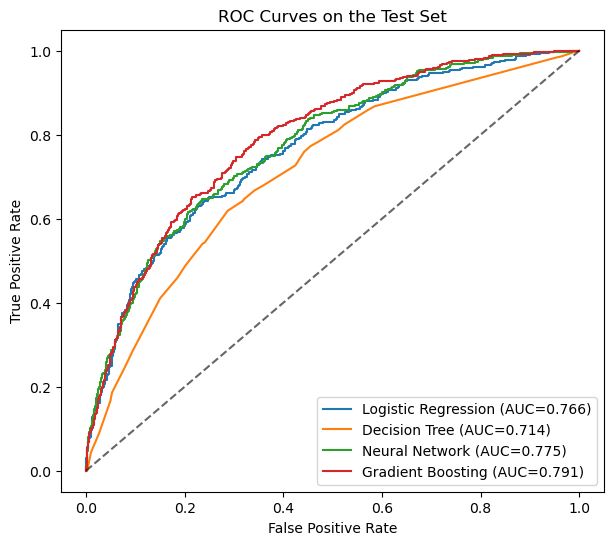

In [19]:
# TODO: overlaid ROC curves for all four models
plt.figure(figsize=(7, 6))
for model_name, model in final_models.items():
    test_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, test_prob)
    auc = roc_auc_score(y_test, test_prob)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.6)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves on the Test Set')
plt.legend()
plt.show()

## 8. Recommended Model

State which model you recommend and why. Show its confusion matrix at your chosen threshold.

I recommend Gradient Boosting for production as lending clubs second optional model. On the held out test set, it produced the highest ROC-AUC, meaning that it ranked risky borrowers better than the other 3 models. The makes it a strong candidate when the business wants to score and prioritize applications for review rather than rely only on a fixed 0.50 cutoff.

For the operating threshold, i do not use the test set, instead i use the validation split inside the training data to choose the threshold that maximizes validation F1. That lowers the cutoff between 0.50 and imrpoves recall. This is useful in a credit risk setting where missing a risky borrower can be costly.

In [20]:
# TODO: confusion matrix for the recommended model
threshold_rows = []
gb_val_prob = gb_val_model.predict_proba(X_val)[:, 1]

for threshold in np.linspace(0.05, 0.95, 181):
    val_pred = (gb_val_prob >= threshold).astype(int)
    threshold_rows.append(
        {'Threshold': threshold,
        'Validation Precision': precision_score(y_val, val_pred, zero_division=0),
        'Validation Recall': recall_score(y_val, val_pred, zero_division=0),
        'Validation F1': f1_score(y_val, val_pred, zero_division=0),})

threshold_table = pd.DataFrame(threshold_rows)
best_threshold = threshold_table.loc[threshold_table['Validation F1'].idxmax(), 'Threshold']

print(f'Chosen threshold from validation set: {best_threshold:.2f}')
threshold_table.sort_values('Validation F1', ascending=False).head(10)

Chosen threshold from validation set: 0.18


,Threshold,Validation Precision,Validation Recall,Validation F1
27,0.185,0.359664,0.722973,0.480359
26,0.180,0.354839,0.743243,0.480349
22,0.160,0.342981,0.800676,0.480243
35,0.225,0.385246,0.635135,0.479592
23,0.165,0.344675,0.787162,0.479424
34,0.220,0.383367,0.638514,0.479087
24,0.170,0.346505,0.770270,0.477987
25,0.175,0.349530,0.753378,0.477516
28,0.190,0.360485,0.702703,0.476518
21,0.155,0.336606,0.810811,0.475719


Test-set metrics at the chosen threshold:
Accuracy : 0.7255
Precision: 0.3709
Recall   : 0.6946
F1       : 0.4835
ROC-AUC  : 0.7911


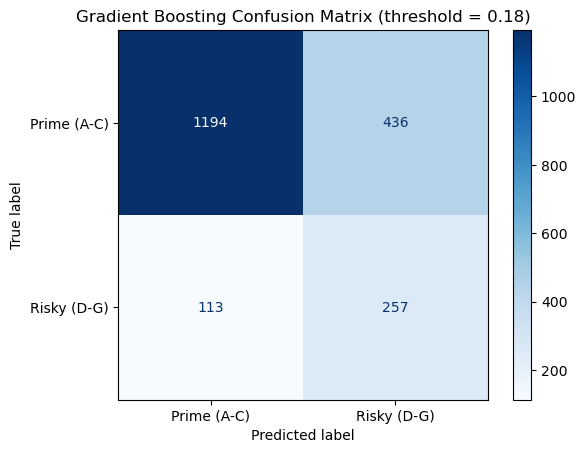

array([[1194,  436],
       [ 113,  257]])

In [21]:
gb_test_prob = gb_final_model.predict_proba(X_test)[:, 1]
gb_test_pred = (gb_test_prob >= best_threshold).astype(int)

print('Test-set metrics at the chosen threshold:')
print('Accuracy :', round(accuracy_score(y_test, gb_test_pred), 4))
print('Precision:', round(precision_score(y_test, gb_test_pred), 4))
print('Recall   :', round(recall_score(y_test, gb_test_pred), 4))
print('F1       :', round(f1_score(y_test, gb_test_pred), 4))
print('ROC-AUC  :', round(roc_auc_score(y_test, gb_test_prob), 4))

cm = confusion_matrix(y_test, gb_test_pred)
ConfusionMatrixDisplay(cm, display_labels=['Prime (A-C)', 'Risky (D-G)']).plot(cmap='Blues')
plt.title(f'Gradient Boosting Confusion Matrix (threshold = {best_threshold:.2f})')
plt.show()
cm

## 9. Interpretation --- Top 5 Features

Rank the top 5 features for your recommended model. Use `feature_importances_` for tree/ensemble, scaled coefficients for logistic regression, or permutation importance for the neural network.

Add a one-sentence business interpretation per feature.

In [22]:
# TODO: top 5 feature importance / coefficient table
feature_names = gb_final_model.named_steps['preprocessor'].get_feature_names_out()
feature_importance = gb_final_model.named_steps['model'].feature_importances_

importance_df = pd.DataFrame(
    {
        'Feature': feature_names,
        'Importance': feature_importance,
    }
).sort_values('Importance', ascending=False)

importance_df['Feature'] = (
    importance_df['Feature']
    .str.replace('num__', '', regex=False)
    .str.replace('cat__', '', regex=False)
)

top5 = importance_df.head(5).copy()
interpretation_map = {
    'term': 'Longer terms, especially 60-month loans, appeared more often among risky-grade borrowers than prime borrowers.',
    'credit_utilization_ratio': 'Applicants using a larger share of their available credit looked riskier to the model.',
    'total_debit_limit': 'Lower total debit limits tended to appear among riskier borrowers, suggesting thinner available credit capacity.',
    'debt_to_income': 'Higher debt-to-income ratios signal heavier existing debt burden and were important in separating risky loans.',
    'loan_amount': 'Larger requested loan amounts carried useful signal in the risk split between prime and risky-grade applicants.',
    'verified_income_Verified': 'Verified income status carried predictive signal, suggesting that the level of income documentation is related to how Lending Club distinguishes prime from riskier applicants.',
    'verified_income_Source Verified': 'Source-verified income carried predictive signal, suggesting documentation quality is related to borrower risk.',
    'verified_income_Not Verified': 'Not-verified income carried predictive signal, suggesting uncertainty around income documentation matters for risk assessment.'
}

top5['Business interpretation'] = top5['Feature'].map(interpretation_map).fillna(
    'This feature was among the strongest predictors in the model and should be interpreted as part of Lending Club’s overall application-risk profile.'
)

top5.reset_index(drop=True)

,Feature,Importance,Business interpretation
0,term,0.196895,"Longer terms, especially 60-month loans, appea..."
1,total_debit_limit,0.156419,Lower total debit limits tended to appear amon...
2,debt_to_income,0.086442,Higher debt-to-income ratios signal heavier ex...
3,loan_amount,0.068096,Larger requested loan amounts carried useful s...
4,verified_income_Verified,0.062406,Verified income status carried predictive sign...
